Importing the Libraries

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

Defining the Secret Bitstring

In [2]:
secret = "11010"
n = len(secret)
print(f"Secret bitstring: {secret}")

Secret bitstring: 11010


Building the Bernstein‑Vazirani Circuit

In [3]:
qc = QuantumCircuit(n + 1, n)

qc.x(n)
qc.h(range(n + 1))

for i, bit in enumerate(reversed(secret)):
    if bit == "1":
        qc.cx(i, n)

qc.h(range(n))
qc.measure(range(n), range(n))

Visualising the Circuit

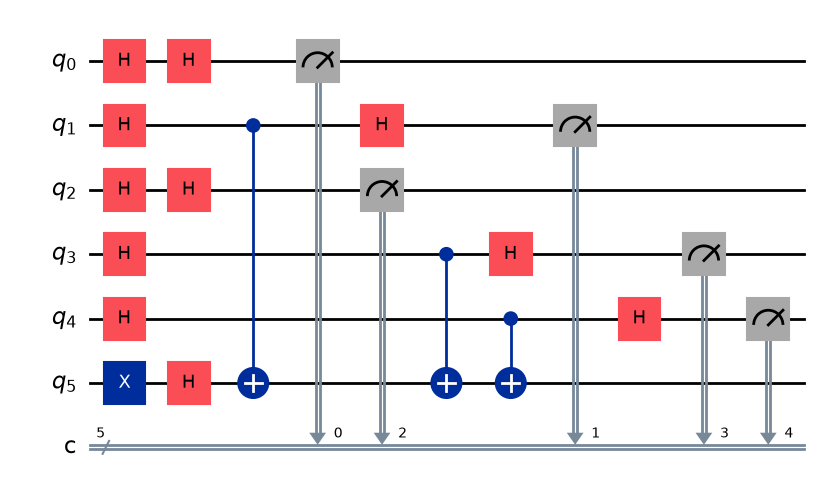

In [4]:
qc.draw('mpl')

Running the Circuit on the AerSimulator

In [5]:
simulator = AerSimulator()
result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()
print("Measurement counts:", counts)

Measurement counts: {'11010': 1024}


Visualising the Results as a Histogram

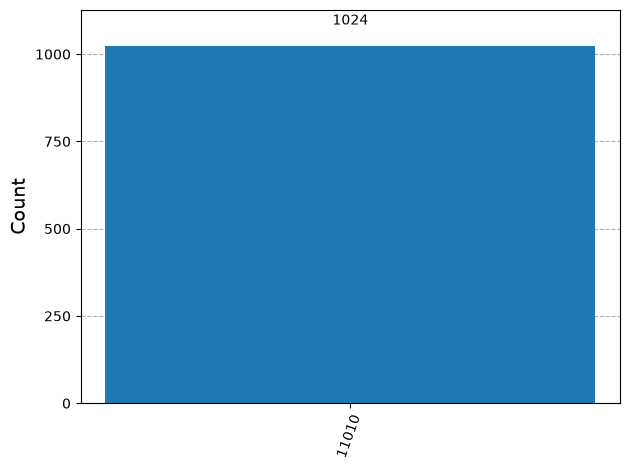

In [11]:
plot_histogram(counts)